Gillespie: lambda_C = (sum transition rates)

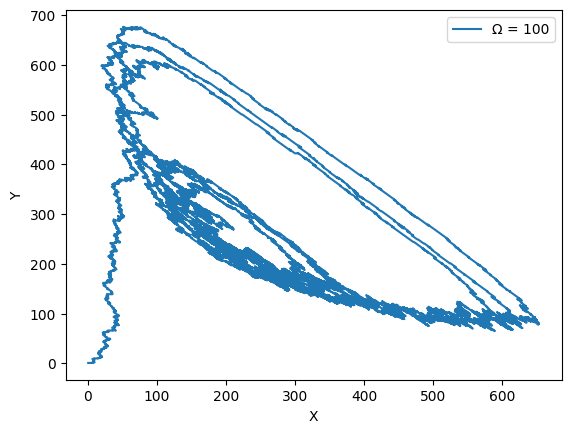

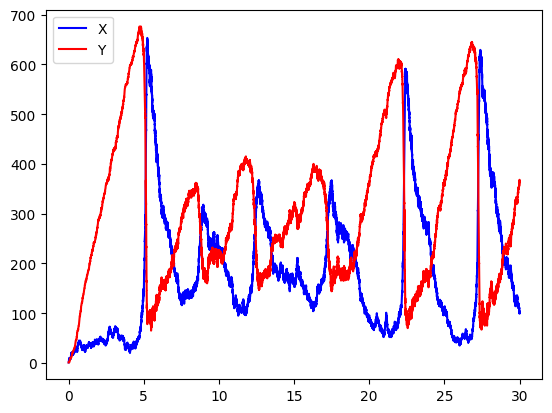

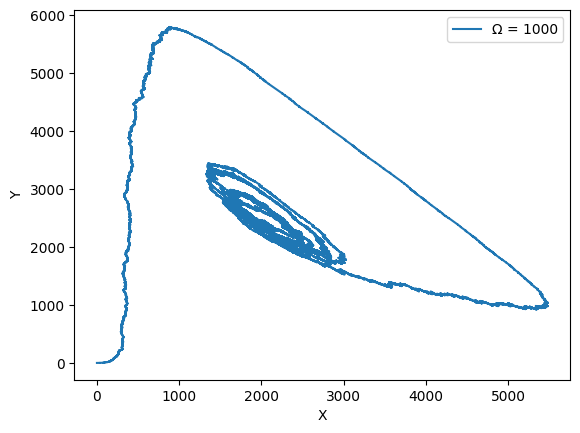

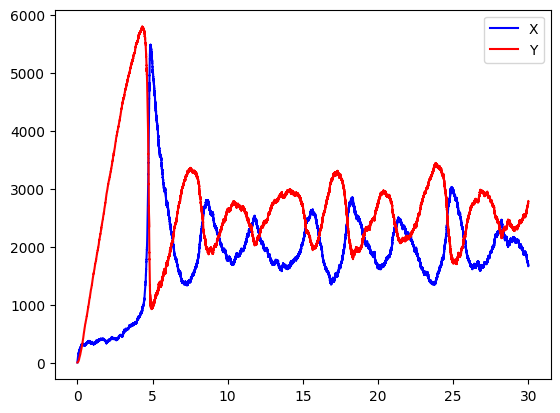

c:\Users\Sofia\Desktop\Programs\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


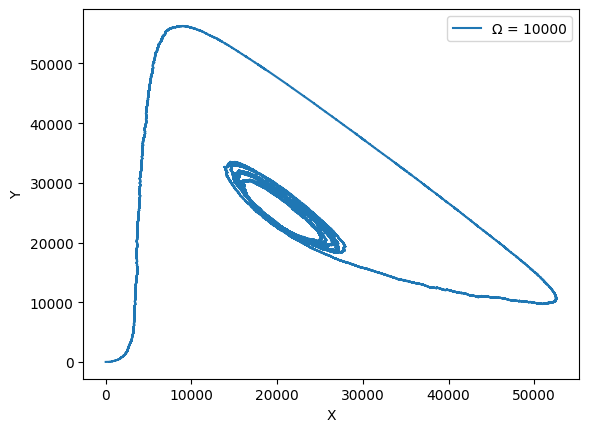

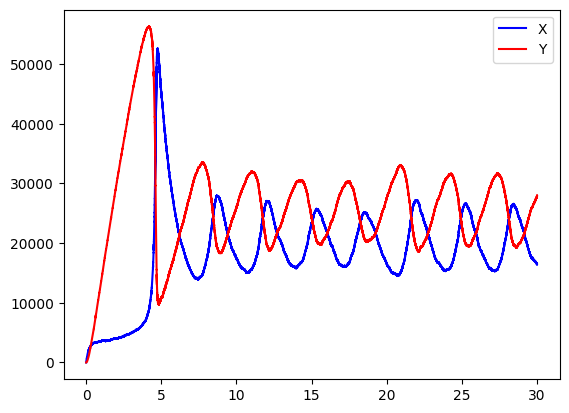

In [ ]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt 

# Parametri del modello
a = 2
b = 5
volumes = [10**2, 10**3, 10**4] 

# Parametri di simulazione
X0, Y0 = 1, 1  # Initial state
t_final = 30  
# Reaction rates
def compute_rates(X, Y, Omega):
    w1 = a * Omega
    w2 = X
    w3 = (1 / Omega**2) * X * (X - 1) * Y
    w4 = b * X
    return w1, w2, w3, w4

def gillespie_brusselator(Omega):
    X, Y = X0, Y0
    t = 0
    times = [t]
    X_values = [X]
    Y_values = [Y]
    
    while t < t_final:
        w1, w2, w3, w4 = compute_rates(X, Y, Omega)
        W_total = w1 + w2 + w3 + w4
        
        if W_total == 0:
            break  
        
        # generating waiting time tau according to W_total * exp(-W_total*t)
        r = random.random()  
        tau = - (1 / W_total) * math.log(1 - r)
        t += tau
        
        rand = np.random.rand() * W_total
        if rand < w1:
            X += 1  # reaction (X, Y) → (X + 1, Y)
        elif rand < w1 + w2:
            X -= 1  # reaction (X, Y) → (X - 1, Y)
        elif rand < w1 + w2 + w3:
            X += 1
            Y -= 1  # reaction (X, Y) → (X + 1, Y - 1)
        else:
            X -= 1
            Y += 1  # reaction (X, Y) → (X - 1, Y + 1)
        
        times.append(t)
        X_values.append(X)
        Y_values.append(Y)
    
    return X_values, Y_values, times 

for Omega in volumes:
    X_values, Y_values, times = gillespie_brusselator(Omega)
    plt.plot(X_values, Y_values, label=f'Ω = {Omega}')
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()
    plt.plot(times, X_values, label='X', color='blue')
    plt.xlabel("time")
    plt.plot(times, Y_values, label='Y', color='red')
    plt.legend()
    plt.show()

    
    print()
